# Practice 3: Customer Clustering - Bước 7.2: Phân tích chân dung khách hàng từ cụm Hierarchical

---

Chúng ta tiến hành phân tích chân dung khách hàng dựa trên kết quả phân cụm của thuật toán **Hierarchical Clustering (Ward Linkage, K = 4)** được thực hiện từ Scratch trên tập con đại diện 1,000 mẫu để phục vụ chiến dịch marketing và định vị dòng xe ô tô phù hợp.

## 1. Import các thư viện và tải dữ liệu

Chúng ta tải dữ liệu gốc đã làm sạch `Train_cleaned.csv` và nhãn phân cụm đại diện Hierarchical từ Scratch (`hierarchical_scratch_labels.npy`). Để đảm bảo tính đồng bộ 1-1 với quá trình huấn luyện, chúng ta tái tạo tập con 1,000 mẫu ngẫu nhiên bằng cách dùng cùng một hàm seed và chỉ số ngẫu nhiên.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

# 1. Tải dữ liệu gốc sạch
df_raw = pd.read_csv('../data/processed/Train_cleaned.csv')

# 2. Tái tạo tập con 1000 mẫu ngẫu nhiên đồng bộ với 06_hierarchical.ipynb
np.random.seed(42)
sub_train_idx = np.random.choice(df_raw.shape[0], 1000, replace=False)

# 3. Tải nhãn Hierarchical từ Scratch
hier_labels = np.load('../models/hierarchical_scratch_labels.npy')

# 4. Trích xuất tập con gốc và ghép nhãn
df_hier = df_raw.iloc[sub_train_idx].copy()
df_hier['Cluster'] = hier_labels

print(f'Kích thước tập dữ liệu con được ghép nhãn Hierarchical: {df_hier.shape}')
print('Số lượng mẫu trong từng cụm Hierarchical:')
print(df_hier['Cluster'].value_counts().sort_index())

Kích thước tập dữ liệu con được ghép nhãn Hierarchical: (1000, 11)
Số lượng mẫu trong từng cụm Hierarchical:
Cluster
0    141
1    176
2    392
3    291
Name: count, dtype: int64


## 2. Thống kê đặc trưng số học theo cụm

Khảo sát các biến định lượng `Age`, `Work_Experience`, và `Family_Size`.

Age        Work_Experience        Family_Size       
              mean median            mean median        mean median
Cluster                                                            
0        34.602837   31.0        2.609929    1.0    3.056738    3.0
1        31.926136   30.0        2.500000    1.0    3.011364    3.0
2        51.091837   48.5        2.747449    1.0    2.668367    2.0
3        44.443299   42.0        2.848797    1.0    2.470790    2.0

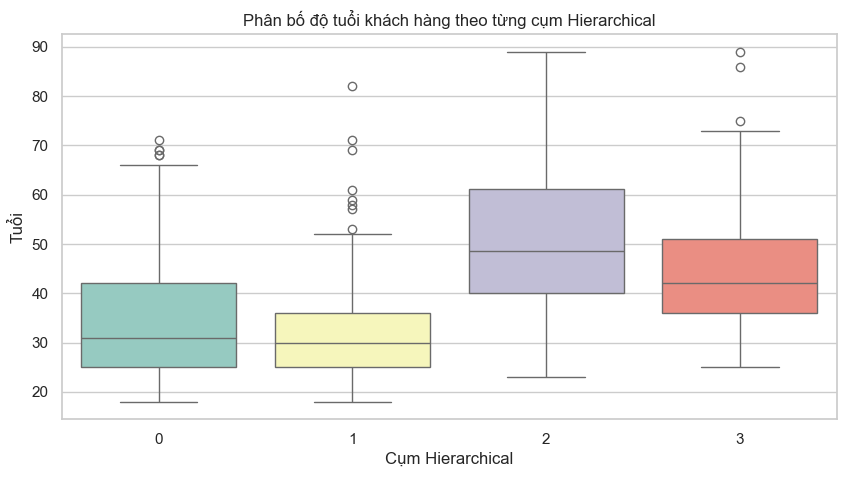

In [2]:
numerical_stats = df_hier.groupby('Cluster')[['Age', 'Work_Experience', 'Family_Size']].agg(['mean', 'median'])
display(numerical_stats)

# Vẽ phân bố độ tuổi của 4 cụm
plt.figure(figsize=(10, 5))
sns.boxplot(x='Cluster', y='Age', data=df_hier, hue='Cluster', palette='Set3', legend=False)
plt.title('Phân bố độ tuổi khách hàng theo từng cụm Hierarchical')
plt.xlabel('Cụm Hierarchical')
plt.ylabel('Tuổi')
plt.show()

## 3. Trực quan hóa tỷ lệ các đặc trưng nhân khẩu học theo cụm (Có gắn số liệu % cụ thể)

Chúng ta vẽ biểu đồ so sánh phân bố tỷ lệ phần trăm các đặc trưng phân loại quan trọng chéo theo cụm, hiển thị rõ số liệu tỷ lệ % trực tiếp trên cột.

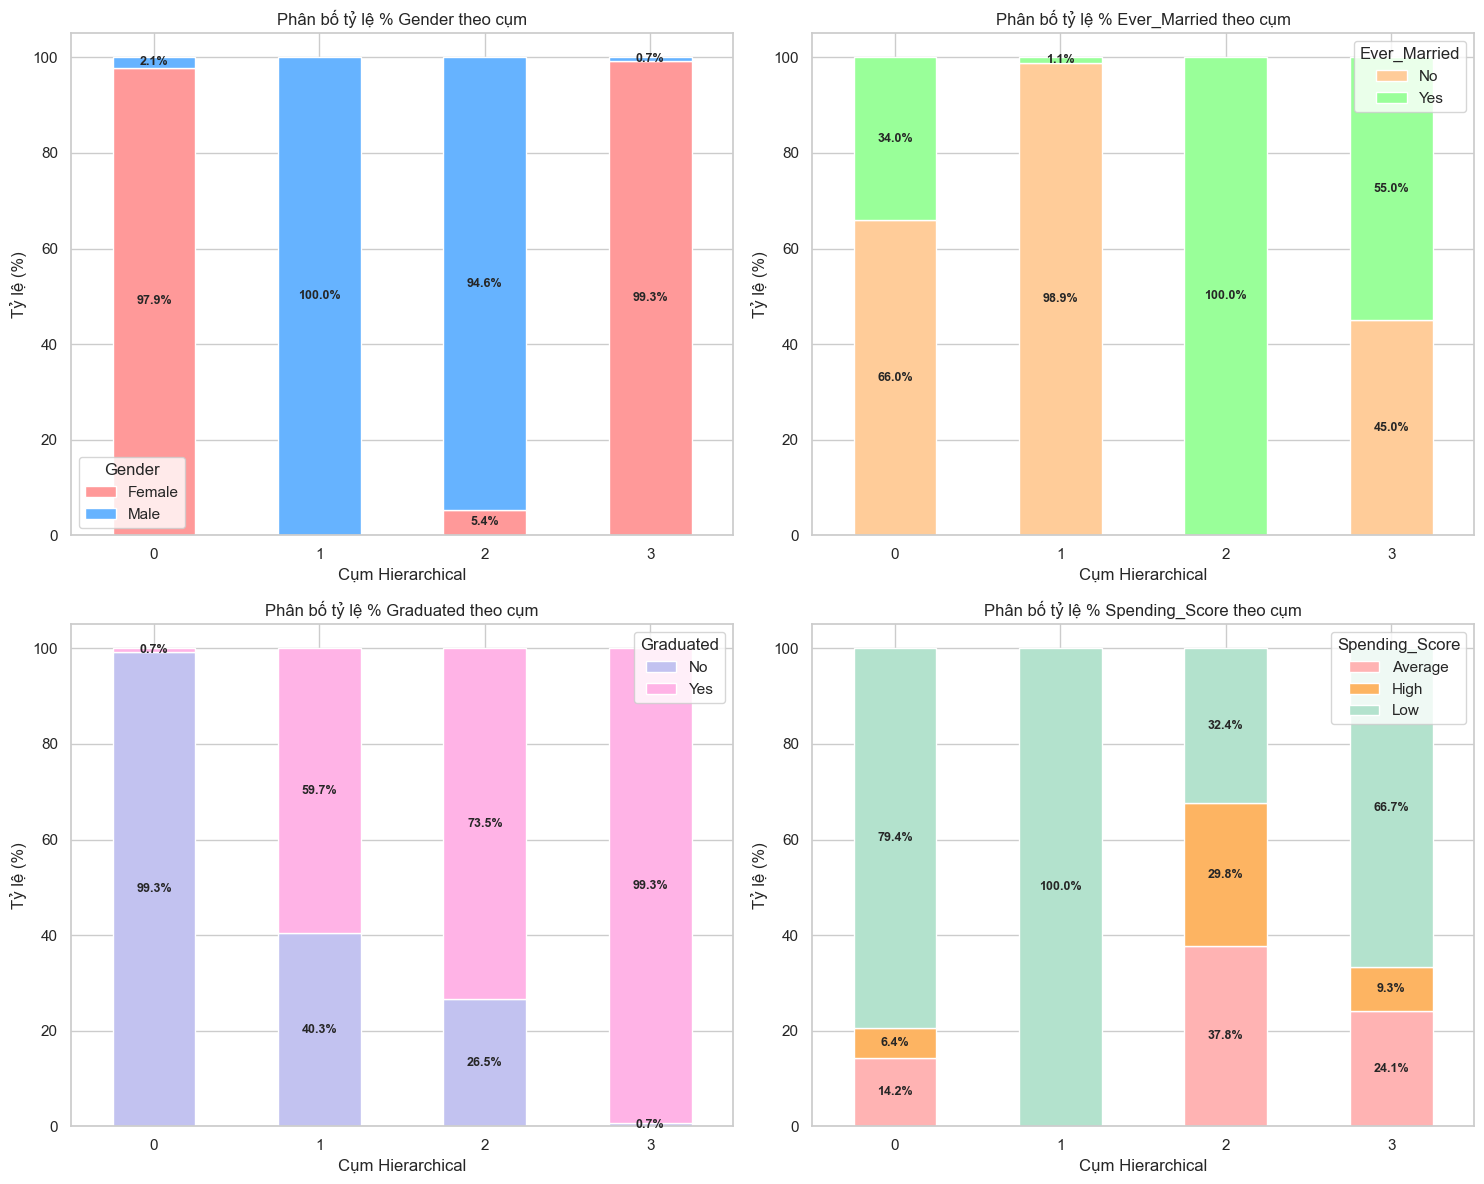

In [3]:
features = ['Gender', 'Ever_Married', 'Graduated', 'Spending_Score']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

# Bảng màu tùy chỉnh hài hòa
colors_dict = {
    'Gender': ['#ff9999', '#66b3ff'],
    'Ever_Married': ['#ffcc99', '#99ff99'],
    'Graduated': ['#c2c2f0', '#ffb3e6'],
    'Spending_Score': ['#ffb3b3', '#fdb462', '#b3e2cd']
}

for idx, col in enumerate(features):
    cross_dist = pd.crosstab(df_hier['Cluster'], df_hier[col], normalize='index') * 100
    ax = axes[idx]
    cross_dist.plot(kind='bar', stacked=True, ax=ax, color=colors_dict[col])
    ax.set_title(f'Phân bố tỷ lệ % {col} theo cụm')
    ax.set_xlabel('Cụm Hierarchical')
    ax.set_ylabel('Tỷ lệ (%)')
    ax.legend(title=col)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    # Thêm nhãn số liệu phần trăm trực tiếp trên cột
    for container in ax.containers:
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

## 4. Trực quan hóa đặc trưng nổi trội của các cụm (Có hiển thị nhãn giá trị)

Chúng ta vẽ biểu đồ so sánh sự khác biệt lớn về Nghề nghiệp (`Profession`) và Mức độ chi tiêu (`Spending_Score`) giữa 4 cụm khách hàng.

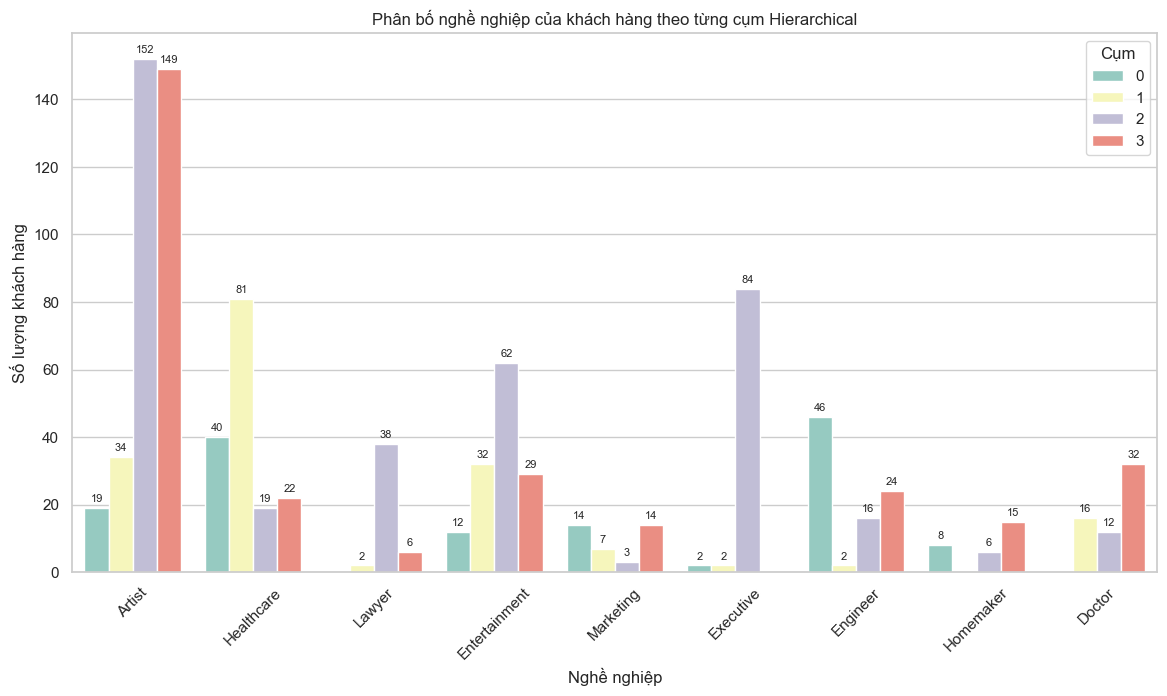

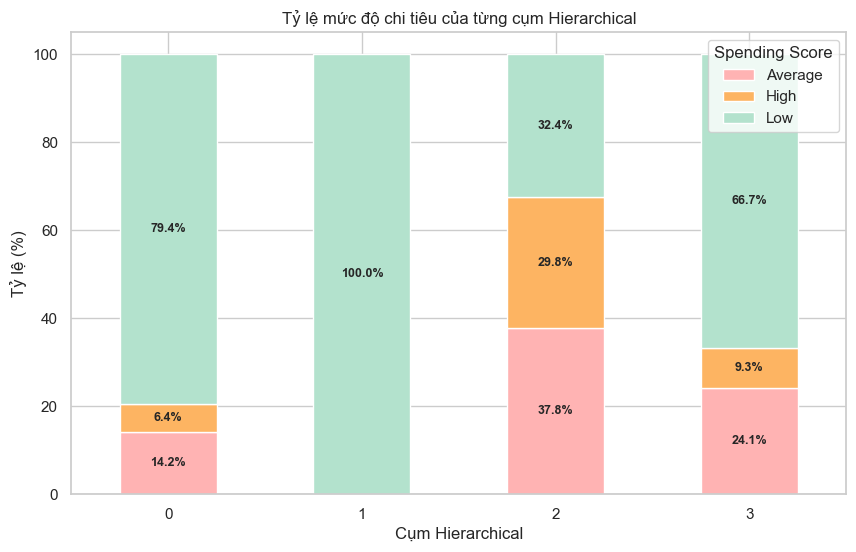

In [4]:
# 4.1. Phân bố Nghề nghiệp theo cụm
plt.figure(figsize=(14, 7))
ax1 = sns.countplot(x='Profession', hue='Cluster', data=df_hier, palette='Set3')
plt.title('Phân bố nghề nghiệp của khách hàng theo từng cụm Hierarchical')
plt.xlabel('Nghề nghiệp')
plt.ylabel('Số lượng khách hàng')
plt.xticks(rotation=45)
plt.legend(title='Cụm')

# Thêm nhãn số lượng mẫu trên cột
for container in ax1.containers:
    ax1.bar_label(container, fontsize=8, padding=3)
plt.show()

# 4.2. Phân bố Mức chi tiêu theo cụm
spending_dist = pd.crosstab(df_hier['Cluster'], df_hier['Spending_Score'], normalize='index') * 100
plt.figure(figsize=(10, 6))
ax2 = plt.gca()
spending_dist.plot(kind='bar', stacked=True, ax=ax2, color=['#ffb3b3', '#fdb462', '#b3e2cd'])
plt.title('Tỷ lệ mức độ chi tiêu của từng cụm Hierarchical')
plt.xlabel('Cụm Hierarchical')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(rotation=0)
plt.legend(title='Spending Score')

# Thêm nhãn số liệu % trên cột chi tiêu
for container in ax2.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
    ax2.bar_label(container, labels=labels, label_type='center', fontsize=9, weight='bold')

plt.show()

## 5. Định hình chân dung khách hàng mua ô tô (Concise Automobile Customer Personas)

Dựa trên kết quả phân tích số liệu từ tập con 1,000 mẫu, chúng ta định hình chân dung 4 nhóm khách hàng Hierarchical cụ thể như sau:

* **Cụm 0: Nữ giới trẻ độc lập, chưa kết hôn (Học vấn tự học, Chi tiêu thấp)**
  * **Đặc trưng số học**: Tuổi trung bình ~34.6 | Gia đình lớn (~3.1 người).
  * **Đặc trưng nhân khẩu học**: 97.9% Nữ | 66.0% Độc thân | 99.3% Chưa tốt nghiệp đại học | ~79.4% Chi tiêu ở mức Thấp (Low).
  * **Nghề nghiệp**: Engineer (32.6%), Healthcare (28.4%), Artist (13.5%).
  * **Dòng xe mục tiêu**: Xe Hatchback hạng B, Sedan cỡ nhỏ, xe điện mini thân thiện.
  * **Chiến lược tiếp thị**: Nhấn mạnh yếu tố kinh tế, sự nhỏ gọn linh hoạt và các gói ưu đãi dịch vụ bảo dưỡng đi kèm.

* **Cụm 1: Nam giới trẻ tuổi trí thức, độc thân (Chi tiêu tối giản)**
  * **Đặc trưng số học**: Tuổi trung bình ~31.9 | Gia đình lớn (~3.0 người).
  * **Đặc trưng nhân khẩu học**: 100% Nam | 98.9% Độc thân | 59.7% Tốt nghiệp đại học | 100.0% Chi tiêu mức Thấp (Low).
  * **Nghề nghiệp**: Healthcare (46.0%), Artist (19.3%), Entertainment (18.2%).
  * **Dòng xe mục tiêu**: Xe Crossover năng động (C-SUV), xe sedan thể thao hướng tới giới trẻ.
  * **Chiến lược tiếp thị**: Các giải pháp tài chính vay mua xe linh hoạt, quảng bá qua mạng xã hội về sự tự do cá nhân và trải nghiệm lái xe.

* **Cụm 2: Nam giới lớn tuổi thành đạt (Đã kết hôn, Trí thức cao)**
  * **Đặc trưng số học**: Tuổi trung bình ~51.1 (lớn nhất) | Gia đình nhỏ (~2.7 người).
  * **Đặc trưng nhân khẩu học**: 94.6% Nam | 100% Đã kết hôn | 73.5% Tốt nghiệp đại học | Chi tiêu Trung bình hoặc Cao đạt ~67.6%.
  * **Nghề nghiệp**: Artist (38.8%), Executive (21.4%), Entertainment (15.8%).
  * **Dòng xe mục tiêu**: Sedan hạng sang cỡ lớn, SUV gia đình cao cấp hạng sang.
  * **Chiến lược tiếp thị**: Các đặc quyền bảo hành VIP, khẳng định phong cách sống đẳng cấp, an toàn và công nghệ tiên phong.

* **Cụm 3: Phụ nữ trung niên thành đạt (Đã kết hôn, Trí thức cao)**
  * **Đặc trưng số học**: Tuổi trung bình ~44.4 | Gia đình nhỏ (~2.5 người).
  * **Đặc trưng nhân khẩu học**: 99.3% Nữ | 55.0% Đã kết hôn | 99.3% Tốt nghiệp đại học (gần như toàn bộ) | Chi tiêu Thấp (~66.7%) hoặc Trung bình (~24.1%).
  * **Nghề nghiệp**: Artist (51.2%), Doctor (11.0%), Entertainment (10.0%).
  * **Dòng xe mục tiêu**: Crossover hạng sang cỡ trung, SUV gia đình 5 chỗ thông minh.
  * **Chiến lược tiếp thị**: Đánh mạnh vào sự tiện dụng, không gian cốp rộng rãi, độ bền bỉ và các tính năng trợ lái an toàn thông minh.